# Multigene subtype-comparison

The previous sections fitted and interpreted one gene in detail. Real analyses generally apply the same model to many genes. 
This notebook demonstrates how to apply BDGDM to a small set of genes and compare CN dosage responses between MSS and MSI tumours.

In [2]:
from __future__ import annotations

import inspect
import platform
from pathlib import Path
from importlib.resources import files

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cmdstanpy
from cmdstanpy import CmdStanModel

import bdgdm
from bdgdm import  BDGDMConfig, load_example_data, fit_one_gene_bdgdm
from bdgdm.posterior import  get_posterior_summary_subtype
from bdgdm.diagnostics import  get_nuts_diagnostics
from bdgdm.preprocessing import prepare_gene_data
from bdgdm.classify import ClassificationThresholds, classify_fit, classify_fits, classification_to_rewiring_df, genes_with_response_class
from bdgdm.plot_fit import plot_ppc_density, plot_copy_number_fit
from bdgdm.plot_classification import classification_wide_to_long, plot_class_distribution

import arviz as az
import xarray as xr

In [4]:
print("Python:", platform.python_version())
print("BDGDM:", getattr(bdgdm, "__version__", "development"))
print("CmdStanPy:", cmdstanpy.__version__)
print("CmdStan:", cmdstanpy.cmdstan_path())

Python: 3.11.7
BDGDM: 0.1.0
CmdStanPy: 1.3.0
CmdStan: /Users/katsiarynadavydzenka/.cmdstan/cmdstan-2.34.1


## Load the example dataset

The example dataset is distributed with BDGDM so that the tutorial can be executed without downloading external data.

In [7]:
data = load_example_data()

print("Rows:", len(data))
print("Genes:", data["gene"].nunique())
print("Samples:", data["sampleID"].nunique())

data.head()

Rows: 104516
Genes: 106
Samples: 986


,gene,sampleID,expr,copies,subtype,purity,ploidy,sf
0,ACVR1B,CRC.SW.U0001.T,7593,2,MSS,0.41,3.8,1.293201
1,ACVR1B,CRC.SW.U0002.T,5003,2,MSS,0.37,3.3,1.024008
2,ACVR1B,CRC.SW.U0004.T,4994,2,MSS,0.58,3.2,1.169870
3,ACVR1B,CRC.SW.U0030.T,6231,2,MSS,0.59,2.2,1.290047
4,ACVR1B,CRC.SW.U0066.T,2908,2,MSS,0.41,1.9,0.971163


## Choose the subtypes

The requested labels are used when available. Otherwise, the two most frequent subtypes are selected.

In [10]:
SELECTED_SUBTYPES = ("MSI", "MSS")
COLUMN_MAP = {
    "gene": "gene",
    "sample": "sampleID",
    "expression": "expr",
    "copy_number": "copies",
    "subtype": "subtype",
    "purity": "purity",
    "size_factor": "sf"
}

MIN_SAMPLES_PER_SUBTYPE = 20
MIN_CN_STATES_PER_SUBTYPE = 2
MIN_ALTERED_PER_SUBTYPE = 10
MIN_MEDIAN_EXPRESSION = 10

subtype_col = COLUMN_MAP["subtype"]
available_subtypes = data[subtype_col].dropna().astype(str).value_counts()
requested = [str(value) for value in SELECTED_SUBTYPES]

if all(value in available_subtypes.index for value in requested):
    selected_subtypes = tuple(requested)
else:
    if len(available_subtypes) < 2:
        raise ValueError("At least two subtype levels are required.")
    selected_subtypes = tuple(available_subtypes.index[:2])
    print("Using the two most frequent subtypes:", selected_subtypes)

(
    data.loc[data[subtype_col].isin(selected_subtypes)]
    .groupby(subtype_col)[COLUMN_MAP["sample"]]
    .nunique()
    .rename("n_samples")
)

subtype
MSI    208
MSS    778
Name: n_samples, dtype: int64

## Select CN-informative genes across subtypes

Subtype comparison requires CNV within every subtype. A gene that is highly variable in MSS but almost entirely diploid in MSI provides
little information about the MSI dosage response.

Genes are therefore filtered separately within each subtype using:

- minimum sample count;
- minimum number of altered samples;
- minimum number of represented CN states;
- minimum expression;
- adequate dosage-design rank.

Eligible genes are ranked using their **minimum CN entropy** and **CN standard deviation** across subtypes. Taking the minimum prevents strong coverage in one subtype from masking weak coverage in another.

In [13]:
def copy_number_entropy(values: pd.Series) -> float:
    probabilities = values.value_counts(normalize=True).to_numpy(dtype=float)
    return float(-np.sum(probabilities * np.log2(probabilities)))


analysis_data = data.loc[data[subtype_col].isin(selected_subtypes)].copy()
analysis_data["is_altered"] = analysis_data[COLUMN_MAP["copy_number"]].ne(2)

cn_by_subtype = (
    analysis_data
    .groupby([COLUMN_MAP["gene"], subtype_col], as_index=False)
    .agg(
        n_samples=(COLUMN_MAP["sample"], "nunique"),
        cn_sd=(COLUMN_MAP["copy_number"], "std"),
        cn_range=(COLUMN_MAP["copy_number"], lambda x: x.max() - x.min()),
        cn_entropy=(COLUMN_MAP["copy_number"], copy_number_entropy),
        n_cn_states=(COLUMN_MAP["copy_number"], "nunique"),
        n_altered=("is_altered", "sum"),
        altered_fraction=("is_altered", "mean"),
        median_expr=(COLUMN_MAP["expression"], "median"),
    )
)

eligible = cn_by_subtype.loc[
    cn_by_subtype["n_samples"].ge(MIN_SAMPLES_PER_SUBTYPE)
    & cn_by_subtype["n_cn_states"].ge(MIN_CN_STATES_PER_SUBTYPE)
    & cn_by_subtype["n_altered"].ge(MIN_ALTERED_PER_SUBTYPE)
    & cn_by_subtype["median_expr"].ge(MIN_MEDIAN_EXPRESSION)
].copy()

gene_rank = (
    eligible
    .groupby(COLUMN_MAP["gene"], as_index=False)
    .agg(
        n_subtypes=(subtype_col, "nunique"),
        minimum_cn_entropy=("cn_entropy", "min"),
        minimum_cn_sd=("cn_sd", "min"),
        minimum_cn_states=("n_cn_states", "min"),
        minimum_altered_samples=("n_altered", "min"),
        total_samples=("n_samples", "sum"),
    )
    .loc[lambda x: x["n_subtypes"].eq(len(selected_subtypes))]
    .sort_values(
        ["minimum_cn_entropy", "minimum_cn_sd", "minimum_altered_samples"],
        ascending=False,
    )
    .reset_index(drop=True)
)

if gene_rank.empty:
    raise ValueError(
        "No gene passed the subtype-specific CN coverage requirements."
    )

gene_rank.head(10)

,gene,n_subtypes,minimum_cn_entropy,minimum_cn_sd,minimum_cn_states,minimum_altered_samples,total_samples
0,TRPS1,2,0.468120,0.291677,3,19,986
1,BRAF,2,0.417189,0.291677,3,16,986
2,FZD3,2,0.406249,0.257189,3,14,986
3,FOXP2,2,0.380782,0.277308,3,14,986
4,KLF5,2,0.380782,0.253552,3,14,986
5,SKA3,2,0.380782,0.253552,3,14,986
6,SLC46A3,2,0.380782,0.253552,3,14,986
7,CYP7B1,2,0.355795,0.251159,2,14,986
8,RBBP7,2,0.351095,0.230471,3,11,986
9,CDKN2A,2,0.334702,0.228040,3,11,986


## Select a small batch of eligible genes

`gene_rank` already contains genes that passed the coverage criteria in every selected subtype. The example uses the highest-ranked genes.

In [16]:
N_EXAMPLE_GENES = 10

multigene_genes = (
    gene_rank[COLUMN_MAP["gene"]]
    .dropna()
    .astype(str)
    .drop_duplicates()
    .head(N_EXAMPLE_GENES)
    .tolist()
)

print(
    f"Selected {len(multigene_genes)} informative genes:"
)
print(multigene_genes)

selected_gene_rank = (
    gene_rank.loc[
        gene_rank[COLUMN_MAP["gene"]]
        .astype(str)
        .isin(multigene_genes)
    ]
    .copy()
    .sort_values(
        [
            "minimum_cn_entropy",
            "minimum_cn_sd",
            "minimum_altered_samples",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

Selected 10 informative genes:
['TRPS1', 'BRAF', 'FZD3', 'FOXP2', 'KLF5', 'SKA3', 'SLC46A3', 'CYP7B1', 'RBBP7', 'CDKN2A']


In [18]:
selected_gene_names = (
    selected_gene_rank[COLUMN_MAP["gene"]]
    .astype(str)
    .tolist()
)

selected_cn_by_subtype = (
    cn_by_subtype.loc[
        cn_by_subtype[COLUMN_MAP["gene"]]
        .astype(str)
        .isin(selected_gene_names)
    ]
    .copy()
    .sort_values(
        [
            COLUMN_MAP["gene"],
            COLUMN_MAP["subtype"],
        ]
    )
    .reset_index(drop=True)
)

## Fit the selected genes

The Stan model is compiled once and reused for every gene. A failure for one gene is recorded without stopping the remaining fits.

The dictionary `fits` has the structure expected by
`classify_fits()`:

```python
{"GENE_A": fit_a,
 "GENE_B": fit_b
}
```

### Sampling configuration

Each gene is fitted independently with four NUTS chains. The same compiled Stan model is reused across genes.

In [22]:
config = BDGDMConfig(
    engine="nuts",
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    adapt_delta=0.90,
    max_treedepth=12,
    return_ppc=False,
    save_draws=False,
    save_summary=False,
    seed=123
)

In [24]:
stan_dir = files("bdgdm").joinpath("stan")

model_single = CmdStanModel(
    stan_file=str(
        stan_dir.joinpath("bdgdm_single.stan")
    )
)

model_subtype = CmdStanModel(
    stan_file=str(
        stan_dir.joinpath("bdgdm_subtype.stan")
    )
)

fits = {}
failed_fits = []

for gene_name in multigene_genes:
    current_gene_df = (
        analysis_data.loc[
            analysis_data[COLUMN_MAP["gene"]]
            .astype(str)
            .eq(gene_name)
        ]
        .copy()
        .reset_index(drop=True)
    )

    try:
        current_fit = fit_one_gene_bdgdm(
            gene_df=current_gene_df,
            gene=gene_name,
            model_single=model_single,
            model_subtype=model_subtype,
            config=config,
        )

        fits[gene_name] = current_fit

    except Exception as error:
        failed_fits.append(
            {
                "gene": gene_name,
                "error_type": type(error).__name__,
                "error_message": str(error),
            }
        )

failed_fits_df = pd.DataFrame(
    failed_fits,
    columns=[
        "gene",
        "error_type",
        "error_message",
    ],
)

print("Successful fits:", len(fits))
print("Failed fits:", len(failed_fits_df))

11:23:07 - cmdstanpy - INFO - CmdStan start processing
11:23:07 - cmdstanpy - INFO - Chain [1] start processing
11:23:07 - cmdstanpy - INFO - Chain [2] start processing
11:23:07 - cmdstanpy - INFO - Chain [3] start processing
11:23:07 - cmdstanpy - INFO - Chain [4] start processing
11:23:19 - cmdstanpy - INFO - Chain [3] done processing
11:23:19 - cmdstanpy - INFO - Chain [2] done processing
11:23:19 - cmdstanpy - INFO - Chain [4] done processing
11:23:20 - cmdstanpy - INFO - Chain [1] done processing
11:23:42 - cmdstanpy - INFO - CmdStan start processing
11:23:42 - cmdstanpy - INFO - Chain [1] start processing
11:23:42 - cmdstanpy - INFO - Chain [2] start processing
11:23:42 - cmdstanpy - INFO - Chain [3] start processing
11:23:42 - cmdstanpy - INFO - Chain [4] start processing
11:24:55 - cmdstanpy - INFO - Chain [2] done processing
11:24:59 - cmdstanpy - INFO - Chain [3] done processing
11:25:00 - cmdstanpy - INFO - Chain [4] done processing
11:59:17 - cmdstanpy - INFO - Chain [1] do

Successful fits: 10
Failed fits: 0


## Inspect diagnostics across genes

Model fitting and posterior validity are evaluated separately.

A fit is retained for biological interpretation only when:

- core-parameter R-hat is at or below 1.01;
- bulk effective sample size is adequate;
- no divergent transitions are observed;
- the proportion of retained iterations reaching maximum tree depth is
  acceptable.

Fits failing these criteria are marked as diagnostic failures and are excluded from dosage-response classification. They should not be assigned `UNC`, because `UNC` denotes biological uncertainty from an otherwise valid posterior.

In [27]:
diagnostic_records = []

for gene_name, gene_fit in fits.items():
    diagnostics = gene_fit.diagnostics

    diagnostic_records.append(
        {
            "gene": gene_name,
            "converged": diagnostics.get("converged"),
            "diagnostic_status": diagnostics.get(
                "diagnostic_status"
            ),
            "max_rhat": diagnostics.get("max_rhat"),
            "min_bulk_ess": diagnostics.get("min_bulk_ess"),
            "min_tail_ess": diagnostics.get("min_tail_ess"),
            "n_divergent": diagnostics.get("n_divergent"),
            "max_treedepth_observed": diagnostics.get(
                "max_treedepth_observed"
            ),
            "n_chains": diagnostics.get("n_chains"),
            "n_draws_total": diagnostics.get(
                "n_draws_total"
            ),
            "n_warnings": len(
                diagnostics.get("warnings", [])
            ),
        }
    )

batch_diagnostics = pd.DataFrame(diagnostic_records)

display(batch_diagnostics.sort_values(["diagnostic_status", "max_rhat"], na_position="last").round(3))

,gene,converged,diagnostic_status,max_rhat,min_bulk_ess,min_tail_ess,n_divergent,max_treedepth_observed,n_chains,n_draws_total,n_warnings
8,RBBP7,True,ok,1.000,2377.838,NaN,0,7,4,4000,0
6,SLC46A3,True,ok,1.001,2198.540,NaN,0,6,4,4000,0
2,FZD3,True,ok,1.001,2947.984,NaN,0,6,4,4000,0
7,CYP7B1,True,ok,1.001,1951.160,NaN,0,4,4,4000,0
3,FOXP2,True,ok,1.001,3120.560,NaN,0,5,4,4000,0
4,KLF5,True,ok,1.001,2090.420,NaN,0,7,4,4000,0
5,SKA3,True,ok,1.001,2575.102,NaN,0,7,4,4000,0
0,TRPS1,True,ok,1.001,2817.040,NaN,0,4,4,4000,0
9,CDKN2A,True,ok,1.002,2177.260,NaN,0,6,4,4000,0
1,BRAF,False,warning,128.961,2.006,NaN,0,12,4,4000,2


In the table above, genes with `diagnostic_status == "ok"` can proceed to classification. Genes with failed diagnostics should be investigated individually and excluded from downstream biological summaries until the sampling problem is resolved.

## Gene-dosage classification

`classify_fits()` is the batch counterpart of `classify_fit()`. It accepts a mapping from gene names to `BDGDMFit` objects and returns
one row per gene.

The table retains subtype-specific response classes, transition patterns, posterior contrast evidence, and the overall rewiring
status.

In [31]:
# Define classification thresholds
thresholds = ClassificationThresholds(
    ppd_sig=0.95,
    rope_low=0.05,
    rope_high=0.95,
    dose_prob_sensitive=0.95,
    dose_prob_insensitive=0.95,
    cancel_threshold=0.20,
    overcomp_threshold=1.00,
    hyper_threshold=0.50,
    low_cn_aneup_threshold=5,
)

In [33]:
classified_df = classify_fits(
    fits,
    thresholds=thresholds,
)

classified_df.head()

,gene,status,fit_flag,analysis_mode,N,n_aneup,cna,S,subtype_levels,subtype_levels_str,...,hyper_supported_2to4_s2,hyper_evidence_method_2to4_s2,reverse_supported_2to4_s2,response_class_MSS,response_reason_MSS,response_subclass_MSS,transition_2to1_MSS,transition_2to3_MSS,transition_2to4_MSS,summary_label
0,TRPS1,ok,ok,subtype_comparison,986,195,all,2,"[MSI, MSS]",MSI|MSS,...,False,credible_interval,False,UNC,insufficient_or_inconsistent_support,ambiguous,weak,weak,weak,"DE | rewiring_uncertain | MSI:UNC,MSS:UNC"
1,BRAF,ok,warn,subtype_comparison,986,139,all,2,"[MSI, MSS]",MSI|MSS,...,False,credible_interval,False,UNC,insufficient_or_inconsistent_support,ambiguous,weak,weak,weak,"DE-uncertain | rewiring_uncertain | MSI:UNC,MS..."
2,FZD3,ok,ok,subtype_comparison,986,221,all,2,"[MSI, MSS]",MSI|MSS,...,False,credible_interval,False,DSG,supported_dsg_pattern,None,proportional,proportional,proportional,"DE-uncertain | rewiring_uncertain | MSI:DSG,MS..."
3,FOXP2,ok,ok,subtype_comparison,986,138,all,2,"[MSI, MSS]",MSI|MSS,...,False,credible_interval,False,DSG,supported_dsg_pattern,None,proportional,proportional,proportional,"DE | rewiring_uncertain | MSI:UNC,MSS:DSG"
4,KLF5,ok,ok,subtype_comparison,986,340,all,2,"[MSI, MSS]",MSI|MSS,...,False,credible_interval,False,DCG,supported_dcg_pattern,None,buffered,weak,buffered,"DE-null | rewiring_uncertain | MSI:DCG,MSS:DCG"


## Visualize representative CN–expression fits

The following genes were selected to illustrate different inferred response patterns rather than to present every fitted gene.

Each panel compares the observed expression values with the posterior fitted CN–expression relationship for each subtype. The central fitted estimate shows the posterior median, while the shaded region represents the selected credible interval.

Predictions at CN states with few or no observations are largely extrapolative and should be interpreted cautiously.

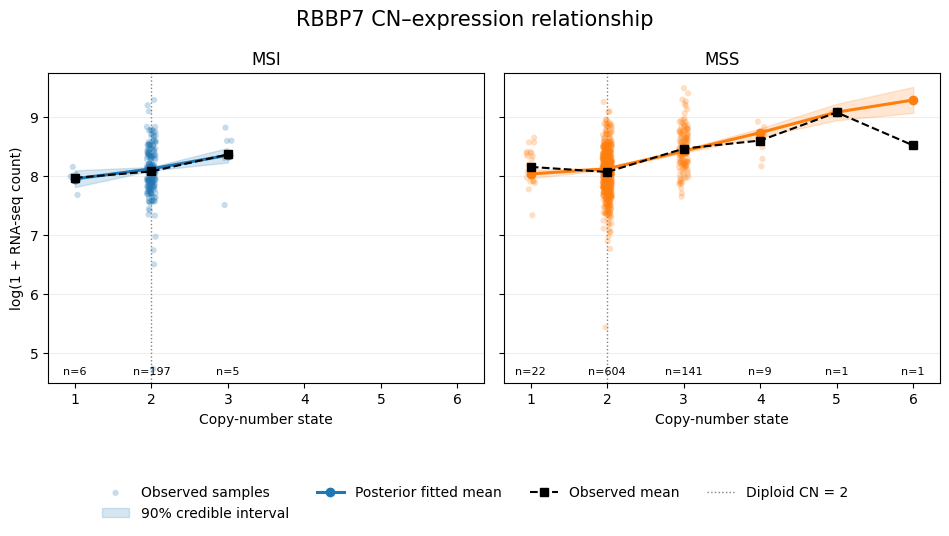

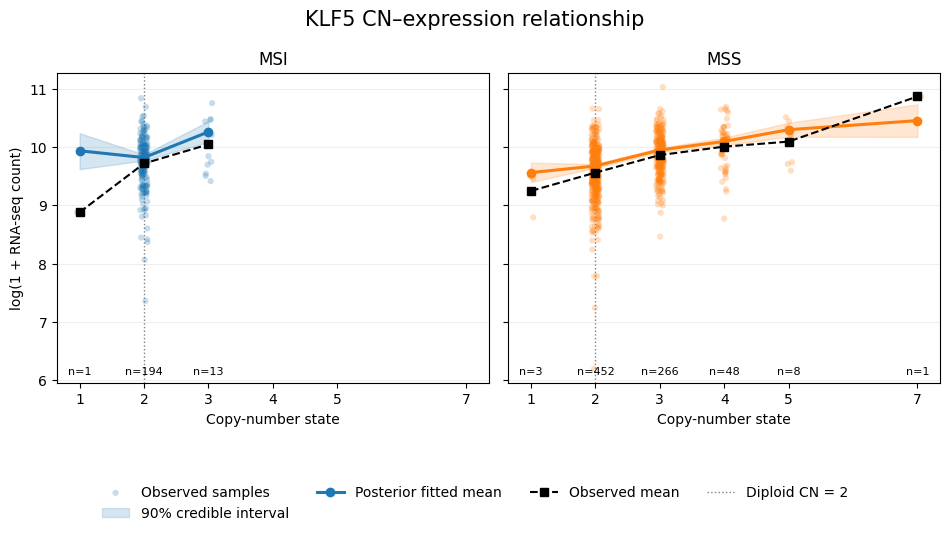

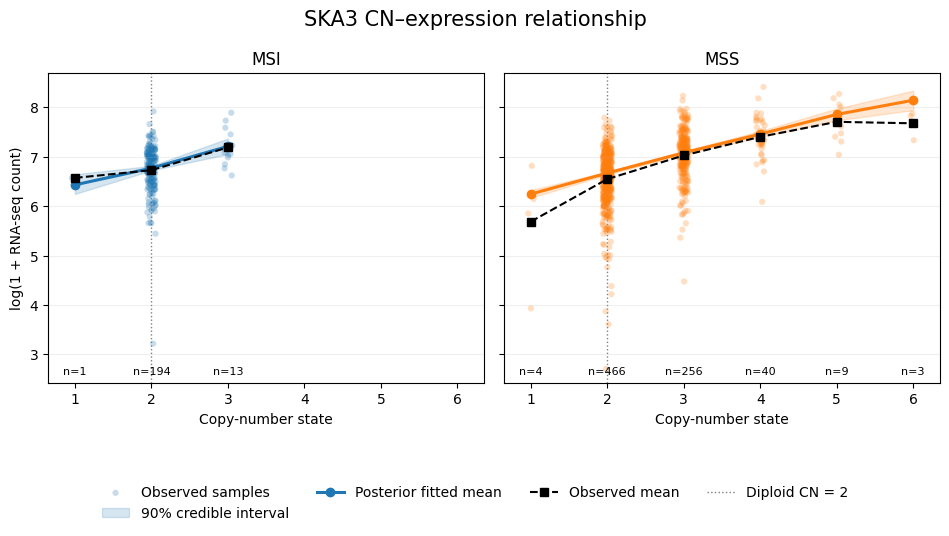

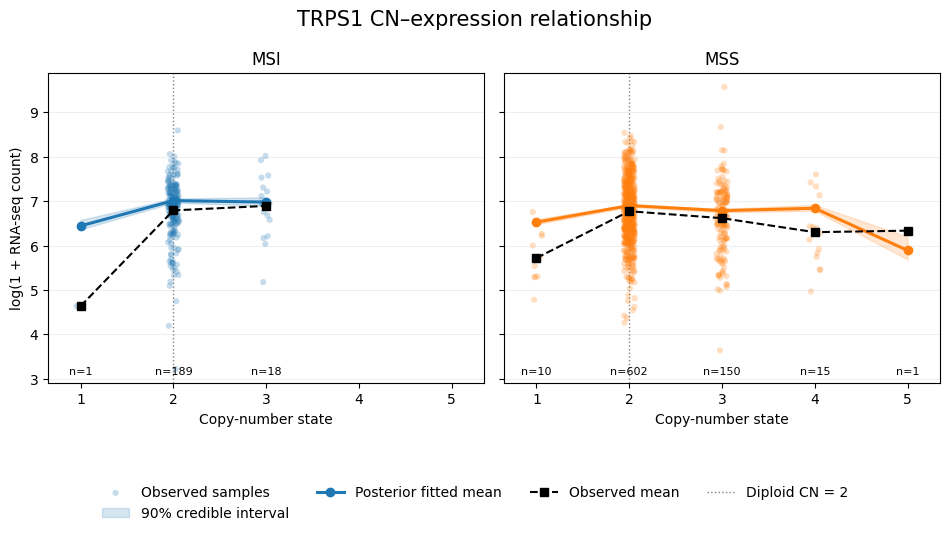

In [36]:
selected_plot_genes = [
    "RBBP7",
    "KLF5",
    "SKA3",
    "TRPS1"
]

cn_summaries = {}

for gene in selected_plot_genes:
    if gene not in fits:
        print(f"Skipping {gene}: no fitted result available.")
        continue

    result = fits[gene]

    processed_df, stan_data, metadata = prepare_gene_data(
        gene_df=analysis_data,
        gene=gene,
        subtype_col="subtype",
        subtype_order=list(SELECTED_SUBTYPES),
    )

    fig, cn_summary = plot_copy_number_fit(
        result,
        processed_df,
        credible_interval=0.90,
    )
    cn_summaries[gene] = cn_summary
    plt.show()

## Interpretation of subtype-specific dosage-response classes

The fitted posterior is continuous, whereas the final response class is a discrete summary. 
Classification combines posterior transition effects, directional probabilities, ROPE probabilities, and credible-interval support using predefined thresholds.

Possible outputs include:

- **DSG**: proportional CN–expression response;
- **DCG**: an attenuated response relative to proportional dosage scaling;
- **HYPER**: a response stronger than the proportional expectation;
- **Mixed**: different response patterns supported by different CN transitions;
- **UNC**: the posterior is valid, but the evidence is insufficient for a specific response class;
- **DIG**: little or no supported expression response to CN change.

In [39]:
classified_long = classification_wide_to_long(classified_df)
classified_long[
    [
        "gene",
        "subtype",
        "response_class",
        "b_scaling_median",
        "b_deviation_median",
    ]
].head(10)

,gene,subtype,response_class,b_scaling_median,b_deviation_median
0,TRPS1,MSI,UNC,0.678582,0.104575
1,BRAF,MSI,UNC,0.639647,0.353007
2,FZD3,MSI,DSG,1.208825,0.196375
3,FOXP2,MSI,UNC,0.783931,0.151410
4,KLF5,MSI,DCG,0.677353,-0.130709
5,SKA3,MSI,DSG,1.227295,-0.026917
6,SLC46A3,MSI,DSG,1.442260,0.027358
7,CYP7B1,MSI,UNC,0.348830,-0.045101
8,RBBP7,MSI,Mixed,0.242267,0.443713
9,CDKN2A,MSI,UNC,-0.404405,-0.167572


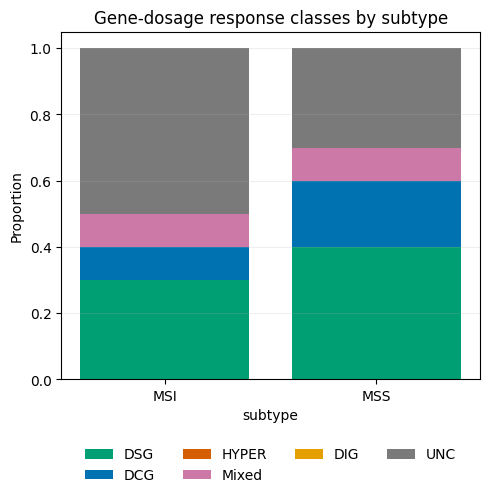

In [41]:
fig, ax, class_summary = plot_class_distribution(
    classified_long,
    classification_col="response_class",
    group_col="subtype",
    normalize=True,
    title="Gene-dosage response classes by subtype",
)

## Interpretation and limitations

This example demonstrates the multigene workflow on a small, selected set of CN-informative genes.

Important limitations are:
- subtype-specific estimates depend on within-subtype CN coverage;
- `b_scaling` and `b_deviation` may be difficult to separate when only a small number of CN states are represented;
- assignment to response classes depend on the specified posterior thresholds.

## Scaling to larger analyses

For tens to thousands of genes, the same biological workflow should be combined with:

- parallel execution across genes;
- deterministic per-gene random seeds;
- pre-filtering for expression and CN-state support;
- saved posterior summaries rather than all draws when storage is limited.